# Tópico 06 – Intervalos de Confiança I [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I/images/colag_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 6.5%;">](https://colab.research.google.com/github/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I/images/github_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 3.25%;">](https://github.com/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I/T%C3%B3pico%2006%20%E2%80%93%20Intervalos%20de%20Confian%C3%A7a%20I.ipynb)




### MATERIAL EM CONSTRUÇÃO [!]

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports para esse tópico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
import math as math
plt.style.use('ggplot')

## Opções de como printar objetos do Numpy e do Pandas
np.set_printoptions(threshold = 20, precision = 2, suppress = True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

## Exemplo #1: $Poisson(\lambda)$

In [2]:
"""
Exemplo #1: Y_i ~ iid. Poisson(lambda)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Quantidade de amostras independentes
m = int(1e3)

## Parâmetros da simulação
lam = 2 # taxa da Poisson
mu = 2 # média populacional

## Declarando objetos
mIC = np.zeros((m, 2))

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.poisson(lam = lam, size = n) # gerando amostra
    mIC[j, :] = [vY.mean() - 2*np.sqrt(lam)/np.sqrt(n), vY.mean() + 2*np.sqrt(lam)/np.sqrt(n)] # calculando o IC95%

In [3]:
## Amostra dos ICs
mIC

array([[1.91, 2.09],
       [1.89, 2.07],
       [1.81, 1.98],
       ...,
       [1.89, 2.06],
       [1.94, 2.12],
       [1.93, 2.11]], shape=(1000, 2))

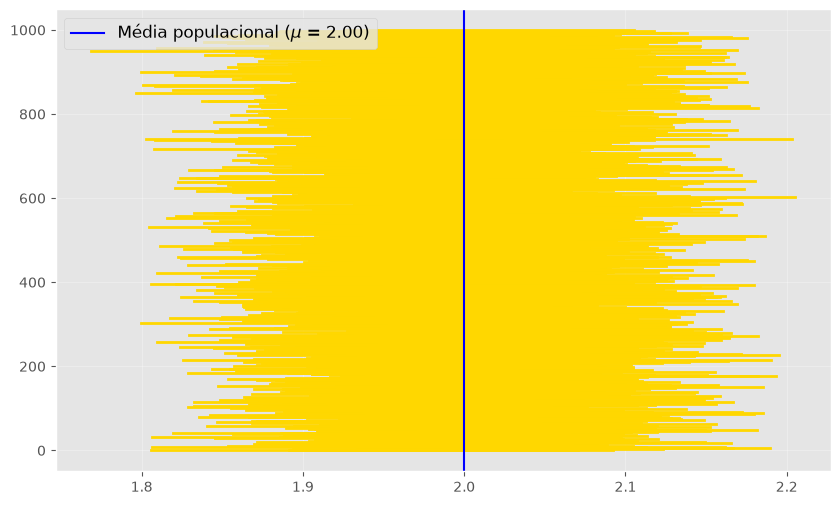

In [4]:
## Visualizando os ICs
plt.figure(figsize = (10, 6))
for j, IC in enumerate(mIC):
    plt.plot([IC[0], IC[1]], [j, j], color = 'gold', linewidth = 2)
plt.axvline(x = mu, color = 'blue', label = f'Média populacional ($\\mu$ = {mu:.2f})')
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

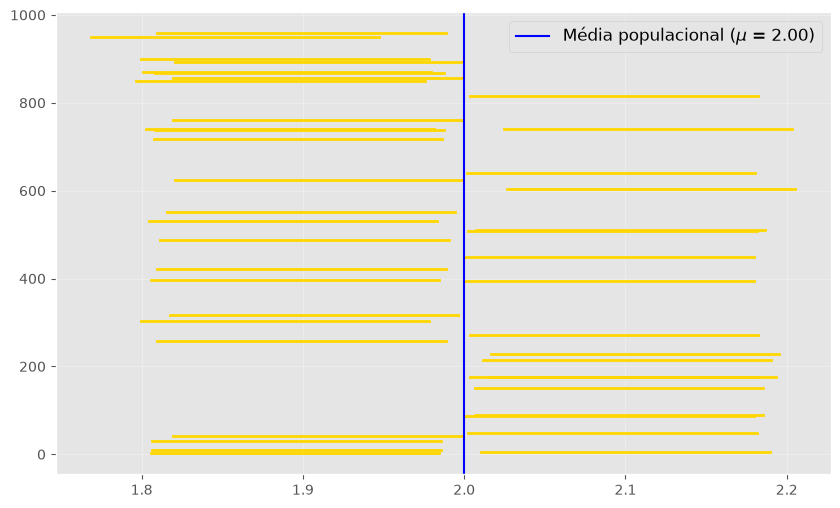

In [5]:
## Visualizando os ICs **que não contém o parâmetro verdadeiro** 
plt.figure(figsize = (10, 6))
count_outside = 0
for j, IC in enumerate(mIC):
    if IC[0] > mu or IC[1] < mu:
        plt.plot([IC[0], IC[1]], [j, j], color = 'gold', linewidth = 2)
        count_outside = count_outside + 1
plt.axvline(x = mu, color = 'blue', label = f'Média populacional ($\\mu$ = {mu:.2f})')
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

In [6]:
## Percentual de ICs que **não contém o verdadeiro valor do parâmetro**
1e2*count_outside/m

4.3

## Exemplo #2: $Beta(\alpha, 1)$

In [7]:
"""
Exemplo #2: Y_i ~ iid. Beta(\alpha, 1)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Parâmetros da simulação
alpha = 1./2 # forma da Beta
beta = 1 # outro parâmetro de forma da Beta :)
mu = alpha / (alpha + beta) # média populacional
sigma2 = (alpha * beta) / ( ((alpha + beta) ** 2) * (alpha + beta + 1) )

## Declarando objetos
vY_bar = np.zeros(m)

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.beta(a = alpha, b = 1, size = n) # gerando amostra
    mIC[j, :] = [vY.mean() - 2*np.sqrt(sigma2)/np.sqrt(n), vY.mean() + 2*np.sqrt(sigma2)/np.sqrt(n)] # calculando o IC95%

In [8]:
## Amostra dos ICs
mIC

array([[0.3 , 0.33],
       [0.32, 0.36],
       [0.33, 0.36],
       ...,
       [0.33, 0.37],
       [0.31, 0.35],
       [0.33, 0.37]], shape=(1000, 2))

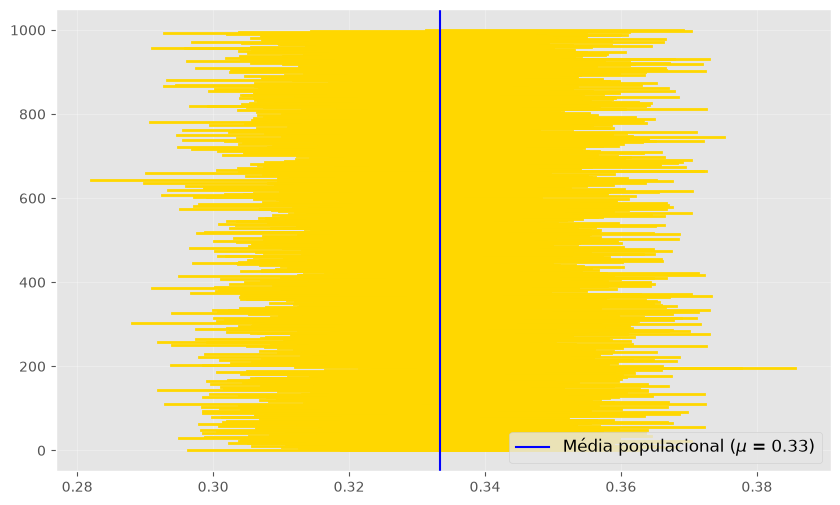

In [9]:
## Visualizando os ICs
plt.figure(figsize = (10, 6))
for j, IC in enumerate(mIC):
    plt.plot([IC[0], IC[1]], [j, j], color = 'gold', linewidth = 2)
plt.axvline(x = mu, color = 'blue', label = f'Média populacional ($\\mu$ = {mu:.2f})')
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

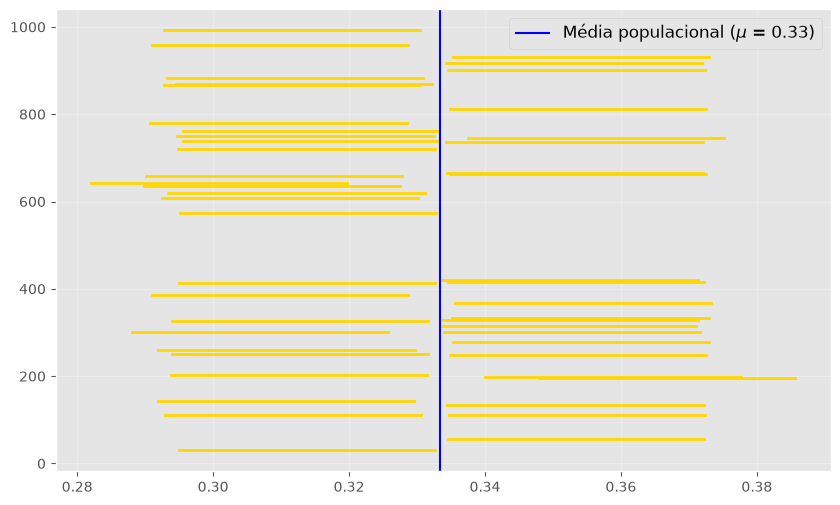

In [10]:
## Visualizando os ICs **que não contém o parâmetro verdadeiro** 
plt.figure(figsize = (10, 6))
count_outside = 0
for j, IC in enumerate(mIC):
    if IC[0] > mu or IC[1] < mu:
        plt.plot([IC[0], IC[1]], [j, j], color = 'gold', linewidth = 2)
        count_outside = count_outside + 1
plt.axvline(x = mu, color = 'blue', label = f'Média populacional ($\\mu$ = {mu:.2f})')
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

In [11]:
## Percentual de ICs que **não contém o verdadeiro valor do parâmetro**
1e2*count_outside/m

4.8